In [1]:
import joblib
import duckdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt



In [2]:

best_model = joblib.load("svr_model.joblib")


In [4]:
con = duckdb.connect()
df = con.execute("""
    SELECT "Time Stamp", Load
    FROM read_parquet('./../../1_LIB/nyiso/nyiso_parquet/**/*.parquet')
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [6]:
df_total_load = df.groupby("Time Stamp", as_index=False)["Load"].sum()
df_total_load.rename(columns={"Time Stamp": "Time"}, inplace=True)

In [7]:
# Ensure the 'Time' column is a datetime type and set it as the index
df_total_load['Time'] = pd.to_datetime(df_total_load['Time'])
df_total_load.set_index('Time', inplace=True)

# Average hourly load
df_hourly = df_total_load.resample('1H').mean().reset_index()
df_hourly = df_hourly.dropna().reset_index()


C:\Users\sarah\AppData\Local\Temp\ipykernel_3276\1013232707.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df_total_load.resample('1H').mean().reset_index()


In [8]:
df_total_load = df_hourly

In [9]:
# Split the data based on the year
train_data = df_total_load[df_total_load['Time'].dt.year.between(2001, 2021)]['Load']
val_data = df_total_load[df_total_load['Time'].dt.year == 2022]['Load']
test_data = df_total_load[df_total_load['Time'].dt.year.isin([2023, 2024, 2025])]['Load']

# Print the sizes of each split
print(f"Training data size: {len(train_data)}")
print(f"Validation data size: {len(val_data)}")
print(f"Testing data size: {len(test_data)}")

scaler = StandardScaler()
train_scaled = scaler.fit_transform(pd.DataFrame(train_data))
val_scaled = scaler.transform(pd.DataFrame(val_data))
test_scaled = scaler.transform(pd.DataFrame(test_data))

Training data size: 179793
Validation data size: 8759
Testing data size: 24094


In [10]:
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X[i:i + time_steps]
        Xs.append(v)
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

TIME_STEPS = 5
X_train, y_train = create_dataset(train_scaled, train_scaled, TIME_STEPS)
X_val, y_val = create_dataset(val_scaled, val_scaled, TIME_STEPS)
X_test, y_test = create_dataset(test_scaled, test_scaled, TIME_STEPS)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(179788, 5, 1) (179788, 1)
(8754, 5, 1) (8754, 1)
(24089, 5, 1) (24089, 1)


In [11]:

# Make predictions
test_pred = best_model.predict(X_test.reshape(X_test.shape[0], -1))

# Inverse scaling
test_pred_inv = scaler.inverse_transform(test_pred.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


In [12]:
# Evaluate the model
mae_test = mean_absolute_error(y_test_inv, test_pred_inv)
print("Tesing MAE:", mae_test)

mape = np.mean(np.abs((y_test_inv - test_pred_inv) / y_test_inv)) * 100
print(f"Testing MAPE: {mape:.2f}%")

rmse = np.sqrt(mean_squared_error(y_test_inv, test_pred_inv))
print(f"Testing RMSE: {rmse}")

r2 = r2_score(y_test_inv, test_pred_inv)
print(f"Testing R2: {r2}")

Tesing MAE: 170.08679543808069
Testing MAPE: 1.00%
Testing RMSE: 348.1292275343323
Testing R2: 0.9872544943594458


In [12]:
#Uncomment for an animation of the results

# import matplotlib.pyplot as plt
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# import numpy as np
# import matplotlib as mpl
# mpl.rcParams['animation.embed_limit'] = 100 

# # Subset of your data
# y_true = y_test_inv
# y_pred = test_pred_inv
# x = np.arange(len(y_true))

# window = 100  # how many points to show at once
# lag = 1       # number of steps prediction lags behind

# fig, ax = plt.subplots(figsize=(10,6))
# line_true, = ax.plot([], [], label="True Values", color="blue", alpha=0.7)
# line_pred, = ax.plot([], [], label="Predictions", color="red", alpha=0.7)
# ax.set_ylim(min(y_true.min(), y_pred.min())*0.95, max(y_true.max(), y_pred.max())*1.05)
# ax.set_xlabel("Index")
# ax.set_ylabel("Load")
# ax.set_title("Predictions vs True Values (Trailing Window)")
# ax.legend()

# def update(frame):
#     start = max(0, frame - window)
#     end = frame
#     line_true.set_data(x[start:end], y_true[start:end])
    
#     # Prediction lags behind true values
#     pred_start = max(0, frame - window - lag)
#     pred_end = max(0, frame - lag)
#     line_pred.set_data(x[pred_start:pred_end], y_pred[pred_start:pred_end])
    
#     ax.set_xlim(x[start], x[end-1] if end > start else x[start]+1)
#     return line_true, line_pred

# ani = FuncAnimation(
#     fig, update,
#     frames=range(0, len(x), 10),   # every 10th frame
#     interval=20, blit=True
# )
# HTML(ani.to_jshtml())



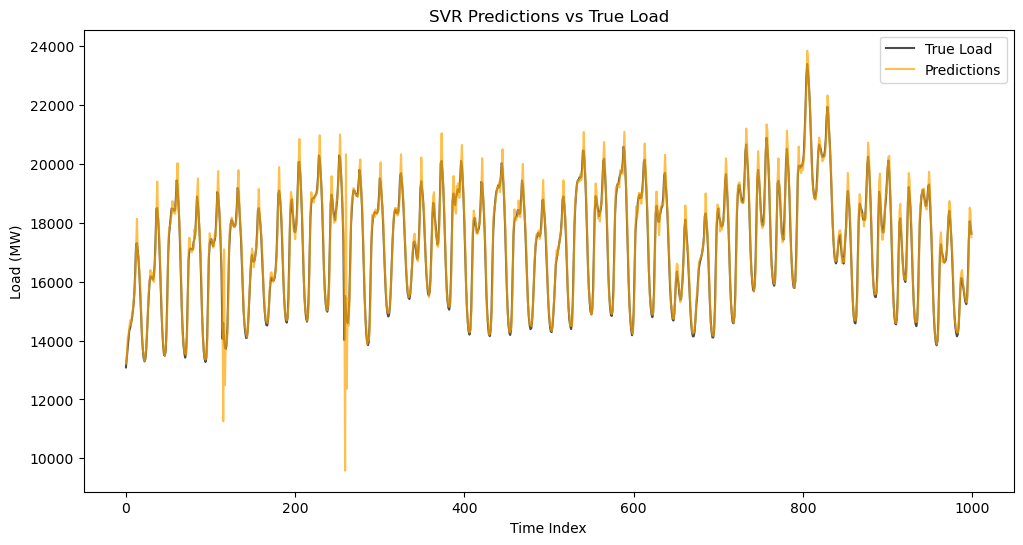

In [13]:
subset_start = 0
subset_end = 1000
plt.figure(figsize=(12,6))
plt.plot(y_test_inv[subset_start: subset_end], label="True Load", color="black", alpha=0.7)
plt.plot(test_pred_inv[subset_start: subset_end], label="Predictions", color="orange", alpha=0.7)
plt.xlabel("Time Index")
plt.ylabel("Load (MW)")
plt.title("SVR Predictions vs True Load")
plt.legend()
plt.show()